# AlexNet — Metrics Visualization

In [1]:
# --- Imports and data loading ---
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("metrics.json") as f:
    metrics = json.load(f)

MODEL_NAME = "AlexNet"

## Training Loss & Accuracy over Epochs

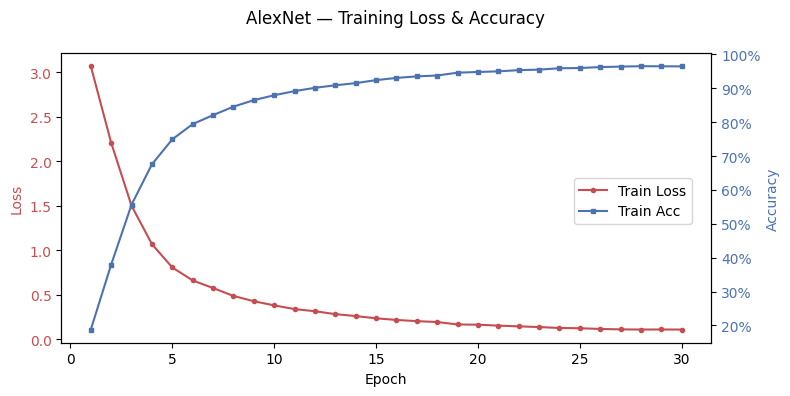

In [2]:
# --- Parse training log and plot loss + accuracy curves ---
import re

log_path = "alexnet_2736396.out"
epochs, losses, accs = [], [], []
with open(log_path) as f:
    for line in f:
        m = re.match(r"Epoch (\d+)/\d+\s+loss=([\d.]+)\s+acc=([\d.]+)", line)
        if m:
            epochs.append(int(m.group(1)))
            losses.append(float(m.group(2)))
            accs.append(float(m.group(3)))

fig, ax1 = plt.subplots(figsize=(8, 4))

# Loss on left axis
ax1.plot(epochs, losses, "o-", color="#C44E52", markersize=3, label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="#C44E52")
ax1.tick_params(axis="y", labelcolor="#C44E52")

# Accuracy on right axis
ax2 = ax1.twinx()
ax2.plot(epochs, accs, "s-", color="#4C72B0", markersize=3, label="Train Acc")
ax2.set_ylabel("Accuracy", color="#4C72B0")
ax2.tick_params(axis="y", labelcolor="#4C72B0")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

fig.suptitle(f"{MODEL_NAME} — Training Loss & Accuracy")
fig.legend(loc="center right", bbox_to_anchor=(0.88, 0.5))
plt.tight_layout()
plt.show()

## Classification Metrics (bar chart)

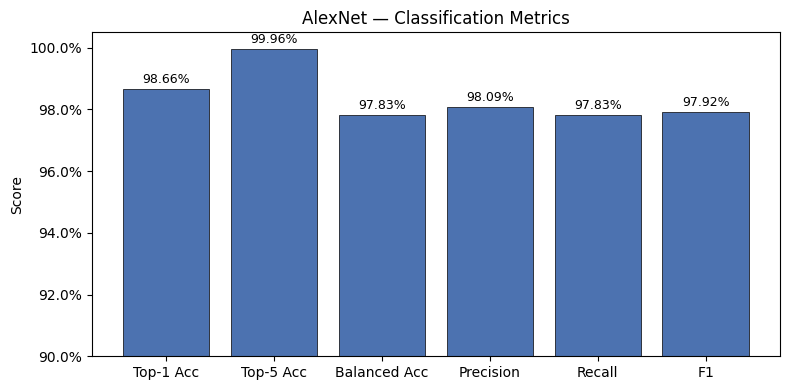

In [3]:
# --- Classification metrics bar chart ---
metric_keys = ["top1_accuracy", "top5_accuracy", "balanced_accuracy",
               "precision_macro", "recall_macro", "f1_macro"]
labels = ["Top-1 Acc", "Top-5 Acc", "Balanced Acc", "Precision", "Recall", "F1"]
values = [metrics[k] for k in metric_keys]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.set_ylim(0.9, 1.005)
ax.set_ylabel("Score")
ax.set_title(f"{MODEL_NAME} — Classification Metrics")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

# annotate each bar
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.001,
            f"{v:.2%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## ROC Curves (per class + macro average)

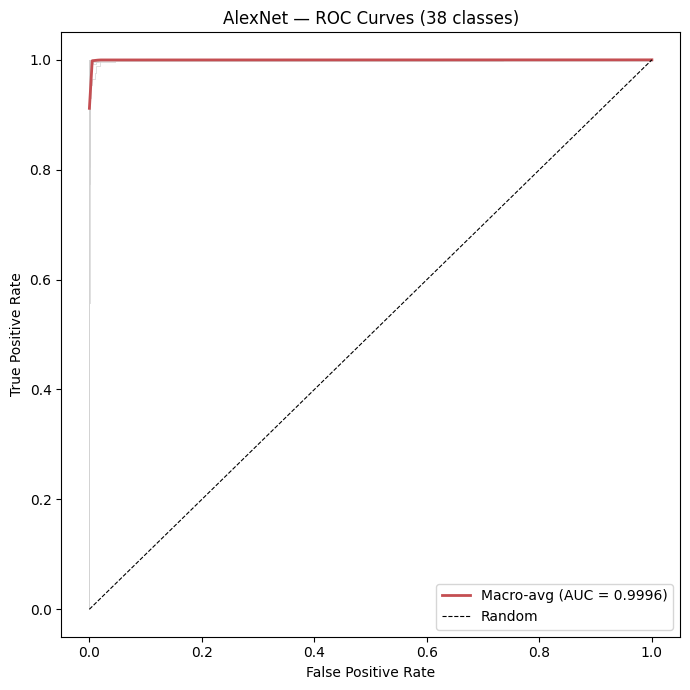

In [4]:
# --- ROC curves ---
roc = metrics["roc_curve"]

fig, ax = plt.subplots(figsize=(7, 7))

# per-class ROC (light gray, thin)
aucs = []
for cls, data in roc.items():
    fpr, tpr = np.array(data["fpr"]), np.array(data["tpr"])
    auc_val = np.trapezoid(tpr, fpr)
    aucs.append(auc_val)
    ax.plot(fpr, tpr, color="lightgray", linewidth=0.5)

# macro-average ROC by interpolation
mean_fpr = np.linspace(0, 1, 200)
mean_tpr = np.zeros_like(mean_fpr)
for data in roc.values():
    mean_tpr += np.interp(mean_fpr, data["fpr"], data["tpr"])
mean_tpr /= len(roc)
macro_auc = np.trapezoid(mean_tpr, mean_fpr)

ax.plot(mean_fpr, mean_tpr, color="#C44E52", linewidth=2,
        label=f"Macro-avg (AUC = {macro_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"{MODEL_NAME} — ROC Curves (38 classes)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Per-Class AUC Distribution

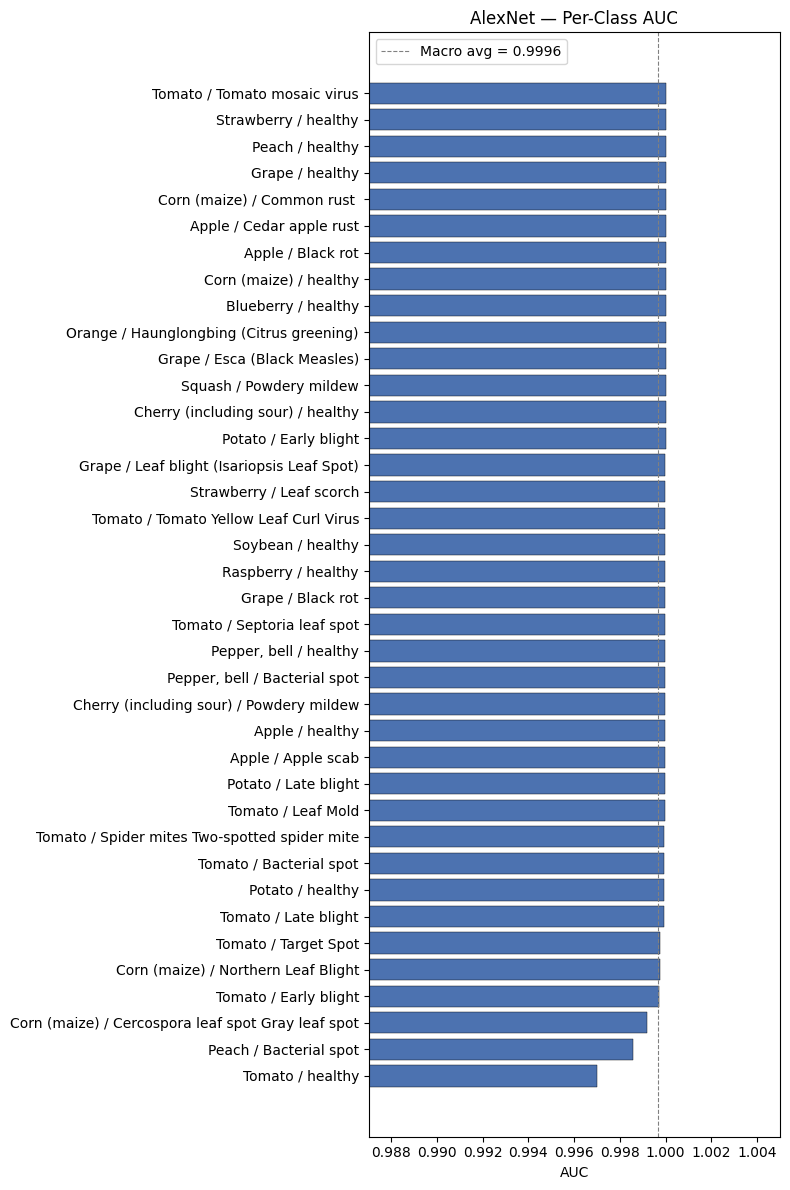

In [5]:
# --- Per-class AUC horizontal bar chart ---
class_aucs = {}
for cls, data in roc.items():
    fpr, tpr = np.array(data["fpr"]), np.array(data["tpr"])
    class_aucs[cls] = np.trapezoid(tpr, fpr)

# sort by AUC ascending (worst at top for readability)
sorted_classes = sorted(class_aucs, key=class_aucs.get)
sorted_aucs = [class_aucs[c] for c in sorted_classes]
# shorten labels: "Tomato___Late_blight" -> "Tomato / Late blight"
short_labels = [c.replace("___", " / ").replace("_", " ") for c in sorted_classes]

fig, ax = plt.subplots(figsize=(8, 12))
colors = ["#C44E52" if a < 0.99 else "#4C72B0" for a in sorted_aucs]
ax.barh(short_labels, sorted_aucs, color=colors, edgecolor="black", linewidth=0.3)
ax.set_xlim(min(sorted_aucs) - 0.01, 1.005)
ax.set_xlabel("AUC")
ax.set_title(f"{MODEL_NAME} — Per-Class AUC")
ax.axvline(x=macro_auc, color="gray", linestyle="--", linewidth=0.8, label=f"Macro avg = {macro_auc:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

## Predictive Entropy

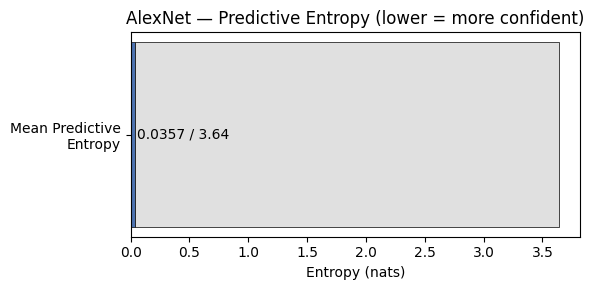

In [6]:
# --- Predictive entropy gauge ---
# Max entropy for 38 classes = log(38)
max_entropy = np.log(38)
ent = metrics["predictive_entropy_mean"]

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["Mean Predictive\nEntropy"], [ent], color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.barh(["Mean Predictive\nEntropy"], [max_entropy - ent], left=[ent], color="#e0e0e0", edgecolor="black", linewidth=0.5)
ax.set_xlim(0, max_entropy * 1.05)
ax.set_xlabel("Entropy (nats)")
ax.set_title(f"{MODEL_NAME} — Predictive Entropy (lower = more confident)")
ax.text(ent + 0.02, 0, f"{ent:.4f} / {max_entropy:.2f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

## Model Size

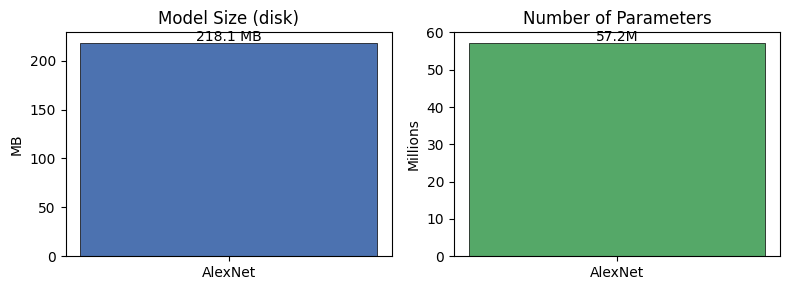

In [7]:
# --- Model size summary ---
size_mb = metrics["model_size_bytes"] / (1024 ** 2)
n_params = metrics["num_parameters"]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].bar([MODEL_NAME], [size_mb], color="#4C72B0", edgecolor="black", linewidth=0.5, width=0.4)
axes[0].set_ylabel("MB")
axes[0].set_title("Model Size (disk)")
axes[0].text(0, size_mb + 2, f"{size_mb:.1f} MB", ha="center", fontsize=10)

axes[1].bar([MODEL_NAME], [n_params / 1e6], color="#55A868", edgecolor="black", linewidth=0.5, width=0.4)
axes[1].set_ylabel("Millions")
axes[1].set_title("Number of Parameters")
axes[1].text(0, n_params / 1e6 + 0.5, f"{n_params / 1e6:.1f}M", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Timing (Train vs Inference)

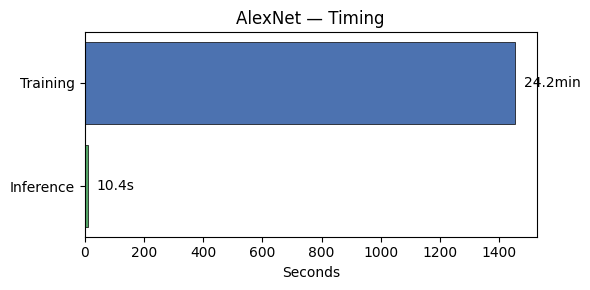

In [8]:
# --- Timing ---
train_t = metrics["train_time_seconds"]
infer_t = metrics["inference_time_seconds"]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(["Inference", "Training"], [infer_t, train_t],
               color=["#55A868", "#4C72B0"], edgecolor="black", linewidth=0.5)
ax.set_xlabel("Seconds")
ax.set_title(f"{MODEL_NAME} — Timing")

# annotate with human-readable times
for bar, t in zip(bars, [infer_t, train_t]):
    label = f"{t:.1f}s" if t < 60 else f"{t/60:.1f}min"
    ax.text(bar.get_width() + max(train_t * 0.02, 1), bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=10)

plt.tight_layout()
plt.show()

## Summary Table (for future multi-model comparison)

In [9]:
# --- Summary table ---
# This cell builds a DataFrame for easy comparison when more models are added.
# Just append rows for new models.
import pandas as pd

row = {
    "Model": MODEL_NAME,
    "Top-1 Acc": f"{metrics['top1_accuracy']:.2%}",
    "Top-5 Acc": f"{metrics['top5_accuracy']:.2%}",
    "Balanced Acc": f"{metrics['balanced_accuracy']:.2%}",
    "Precision": f"{metrics['precision_macro']:.2%}",
    "Recall": f"{metrics['recall_macro']:.2%}",
    "F1": f"{metrics['f1_macro']:.2%}",
    "Entropy": f"{metrics['predictive_entropy_mean']:.4f}",
    "Params (M)": f"{metrics['num_parameters'] / 1e6:.1f}",
    "Size (MB)": f"{metrics['model_size_bytes'] / (1024**2):.1f}",
    "Train (s)": f"{metrics['train_time_seconds']:.1f}",
    "Infer (s)": f"{metrics['inference_time_seconds']:.1f}",
}

df = pd.DataFrame([row]).set_index("Model")
df.T  # transpose for vertical display

Model,AlexNet
Top-1 Acc,98.66%
Top-5 Acc,99.96%
Balanced Acc,97.83%
Precision,98.09%
Recall,97.83%
F1,97.92%
Entropy,0.0357
Params (M),57.2
Size (MB),218.1
Train (s),1454.1
